# Emotionally Driven Music & Podcast Recommender

IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


LOAD ALL DATASETS

In [3]:
BASE = "/Users/sandeep/Desktop/music app/"

journal = pd.read_csv(BASE + "realistic_journal_dataset.csv")
music = pd.read_csv(BASE + "real_spotify_music_dataset.csv")
podcast = pd.read_csv(BASE + "synthetic_podcast_dataset.csv")

music.head(), journal.head(), podcast.head()



(            track_name       artist_name  \
 0           Happy Hits  Weekend Hangouts   
 1  Happy Birthday Song         CoComelon   
 2      Give Up Baby Go         Peach Pit   
 3          Happy B'Day        D Soldierz   
 4           Happy Days          Harshika   
 
                                          spotify_url emotion  
 0  https://open.spotify.com/track/1weF7SQay590Rao...   Happy  
 1  https://open.spotify.com/track/2R5iTxkCln6NLTw...   Happy  
 2  https://open.spotify.com/track/6DIMM15oo3kxnCu...   Happy  
 3  https://open.spotify.com/track/5H0Yfo3acNXU278...   Happy  
 4  https://open.spotify.com/track/78XmLwf0cudyVaS...   Happy  ,
                                           text_entry detected_emotion
 0                   I sat by the window this morning             Calm
 1  The quiet sunrise made me feel centered and gr...             Calm
 2  I took a slow walk through the park breathing ...             Calm
 3            Today felt peaceful with no rush at all      

CLEAN TEXT FUNCTION

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

journal["clean_text"] = journal["text_entry"].apply(clean_text)


EXPLORE JOURNAL DATA

Sample rows:
                                           text_entry detected_emotion  \
0                   I sat by the window this morning             Calm   
1  The quiet sunrise made me feel centered and gr...             Calm   
2  I took a slow walk through the park breathing ...             Calm   
3            Today felt peaceful with no rush at all             Calm   
4  I spent time reading a book with soft music in...             Calm   

                                          clean_text  
0                   i sat by the window this morning  
1  the quiet sunrise made me feel centered and gr...  
2  i took a slow walk through the park breathing ...  
3            today felt peaceful with no rush at all  
4  i spent time reading a book with soft music in...  

Emotion distribution:
detected_emotion
Calm         49
Happy        49
Relaxed      49
Sad          49
Stressed     49
Energetic    47
Name: count, dtype: int64


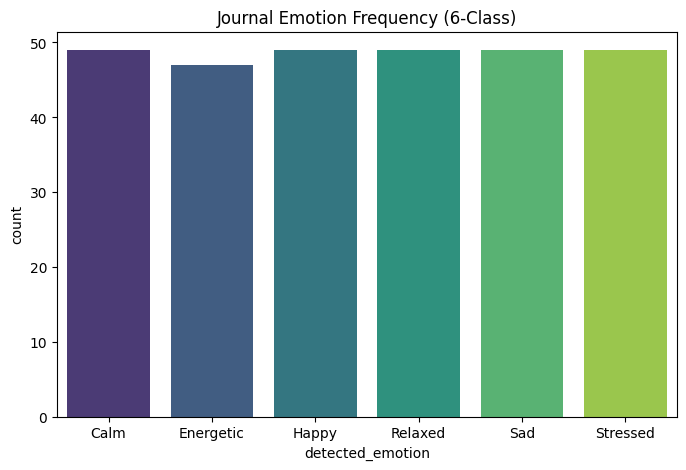

In [5]:
print("Sample rows:\n", journal.head())

print("\nEmotion distribution:")
print(journal["detected_emotion"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x=journal["detected_emotion"], palette="viridis")
plt.title("Journal Emotion Frequency (6-Class)")
plt.show()


WORDCLOUDS (FOR EACH EMOTION)

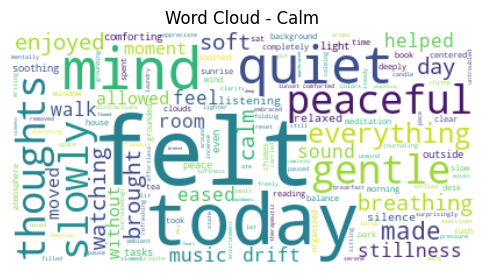

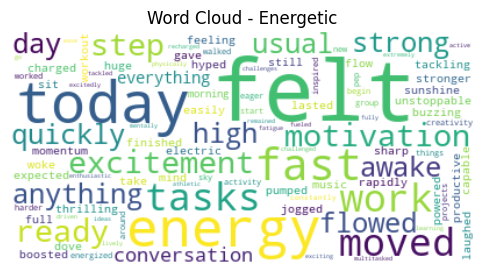

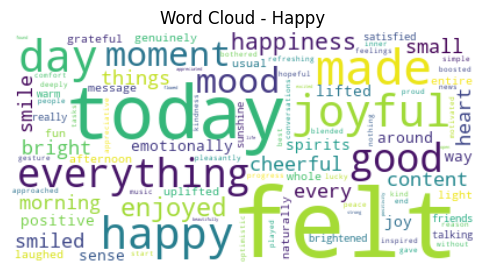

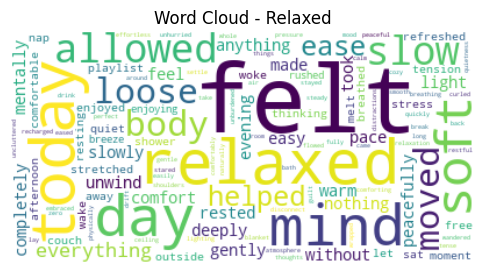

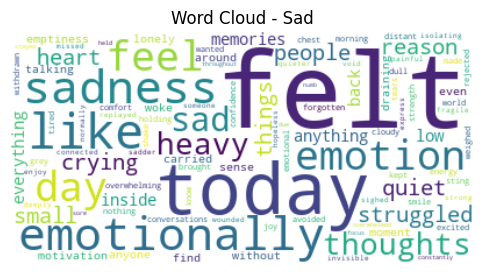

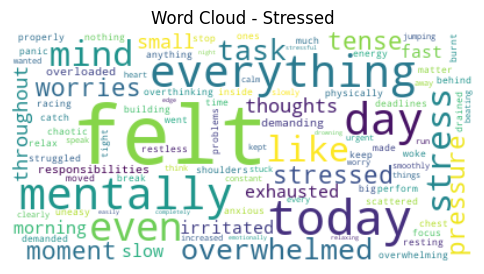

In [6]:
stop = set(stopwords.words("english"))

for emo in journal["detected_emotion"].unique():
    text = " ".join(journal[journal["detected_emotion"] == emo]["clean_text"])
    wc = WordCloud(stopwords=stop, background_color="white").generate(text)
    
    plt.figure(figsize=(6,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud - {emo}")
    plt.show()


CREATE FEATURES (TF-IDF)

In [7]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=5000
)

X = tfidf.fit_transform(journal["clean_text"])
y = journal["detected_emotion"]


TRAIN-TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


TRAIN MULTIPLE MODELS

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=4000),
    "Random Forest": RandomForestClassifier(n_estimators=300),
    "Linear SVM": SVC(kernel="linear", probability=True)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results[name] = {
        "model": model,
        "preds": preds,
        "accuracy": accuracy_score(y_test, preds),
        "macro_f1": f1_score(y_test, preds, average="macro"),
        "report": classification_report(y_test, preds)
    }

    print(results[name]["report"])



Training Logistic Regression...
              precision    recall  f1-score   support

        Calm       0.44      0.58      0.50        12
   Energetic       0.55      0.50      0.52        12
       Happy       0.30      0.25      0.27        12
     Relaxed       0.44      0.33      0.38        12
         Sad       0.62      0.38      0.48        13
    Stressed       0.32      0.50      0.39        12

    accuracy                           0.42        73
   macro avg       0.44      0.43      0.42        73
weighted avg       0.45      0.42      0.42        73


Training Random Forest...
              precision    recall  f1-score   support

        Calm       0.57      0.33      0.42        12
   Energetic       0.32      0.83      0.47        12
       Happy       0.40      0.17      0.24        12
     Relaxed       0.40      0.17      0.24        12
         Sad       0.27      0.31      0.29        13
    Stressed       0.30      0.25      0.27        12

    accuracy     

In [13]:
!pip install transformers datasets accelerate --quiet


Import BERT Libraries

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW


Prepare Dataset for BERT

In [11]:
# Extract text and labels
texts = journal["clean_text"].tolist()
labels = journal["detected_emotion"].astype("category").cat.codes.tolist()

# Save mapping
emotion_labels = list(journal["detected_emotion"].astype("category").cat.categories)
emotion_labels


['Calm', 'Energetic', 'Happy', 'Relaxed', 'Sad', 'Stressed']

Load Tokenizer

In [12]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")


Train/Test Split for BERT

In [13]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.25, random_state=42, stratify=labels
)


Tokenize Text


In [14]:
train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_enc = tokenizer(test_texts, truncation=True, padding=True, max_length=128)


Build PyTorch Dataset

In [15]:
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_enc, train_labels)
test_dataset = EmotionDataset(test_enc, test_labels)


Load DistilBERT Classification Model

In [16]:
num_labels = len(emotion_labels)

model_bert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=num_labels
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Setup

In [17]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

optim = AdamW(model_bert.parameters(), lr=5e-5)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_bert.to(device)

print("Using device:", device)


Using device: mps


Train BERT

In [19]:
epochs = 15

model_bert.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optim.zero_grad()
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model_bert(**batch)
        loss = outputs.loss
        loss.backward()
        optim.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")


Epoch 1/15 - Loss: 0.5237
Epoch 2/15 - Loss: 0.3925
Epoch 3/15 - Loss: 0.3345
Epoch 4/15 - Loss: 0.2680
Epoch 5/15 - Loss: 0.2295
Epoch 6/15 - Loss: 0.1942
Epoch 7/15 - Loss: 0.1694
Epoch 8/15 - Loss: 0.1490
Epoch 9/15 - Loss: 0.1303
Epoch 10/15 - Loss: 0.1150
Epoch 11/15 - Loss: 0.1042
Epoch 12/15 - Loss: 0.0956
Epoch 13/15 - Loss: 0.0900
Epoch 14/15 - Loss: 0.0809
Epoch 15/15 - Loss: 0.0740


Evaluate BERT

In [20]:
model_bert.eval()

preds = []
true = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model_bert(**batch)
        logits = outputs.logits
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true.extend(batch["labels"].cpu().numpy())

print("\nBERT CLASSIFICATION REPORT:\n")
print(classification_report(true, preds, target_names=emotion_labels))



BERT CLASSIFICATION REPORT:

              precision    recall  f1-score   support

        Calm       0.63      1.00      0.77        12
   Energetic       0.91      0.83      0.87        12
       Happy       0.77      0.83      0.80        12
     Relaxed       0.86      0.50      0.63        12
         Sad       1.00      0.62      0.76        13
    Stressed       0.73      0.92      0.81        12

    accuracy                           0.78        73
   macro avg       0.82      0.78      0.78        73
weighted avg       0.82      0.78      0.78        73



BERT Confusion Matrix

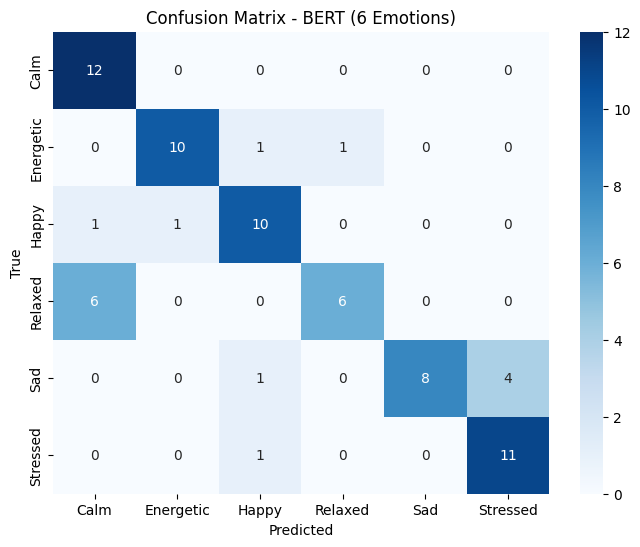

In [21]:
cm = confusion_matrix(true, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title("Confusion Matrix - BERT (6 Emotions)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Save BERT Model

In [22]:
SAVE_PATH = BASE + "bert_emotion_model"

model_bert.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("BERT model saved →", SAVE_PATH)


BERT model saved → /Users/sandeep/Desktop/music app/bert_emotion_model


Emotion prediction

In [23]:
def bert_predict(text):
    model_bert.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k:v.to(device) for k,v in inputs.items()}
    with torch.no_grad():
        logits = model_bert(**inputs).logits
    pred = torch.argmax(logits, dim=1).item()
    return emotion_labels[pred]


Normalize music/podcast datasets

In [24]:
music["emotion"] = music["emotion"].astype(str).str.strip().str.capitalize()
podcast["mood_tag"] = podcast["mood_tag"].astype(str).str.strip().str.capitalize()

print(music["emotion"].unique())
print(podcast["mood_tag"].unique())


['Happy' 'Sad' 'Energetic' 'Calm' 'Stressed' 'Relaxed']
['Happy' 'Sad' 'Calm' 'Stressed' 'Energetic' 'Relaxed']


Music and podcast

In [25]:
def recommend_music(emotion, n=5):
    df = music[music["emotion"] == emotion]
    if df.empty:
        return None
    return df.sample(min(n, len(df)), random_state=42)


In [26]:
def recommend_podcast(emotion, n=5):
    df = podcast[podcast["mood_tag"] == emotion]
    if df.empty:
        return None
    return df.sample(min(n, len(df)), random_state=42)


Final combined function (clean, minimal)

In [27]:
def show_recommendations_from_bert(text, n=5):
    emotion = bert_predict(text)
    
    print("\n======================================")
    print(f" BERT Detected Emotion: {emotion}")
    print("======================================\n")

    # MUSIC
    print(" MUSIC RECOMMENDATIONS\n")
    music_recs = recommend_music(emotion, n)
    if music_recs is not None:
        display(music_recs[["track_name", "artist_name", "spotify_url"]])
    else:
        print("No music found for this emotion.")

    print("\n--------------------------------------\n")

    # PODCAST
    print(" PODCAST RECOMMENDATIONS\n")
    podcast_recs = recommend_podcast(emotion, n)
    if podcast_recs is not None:
        display(podcast_recs[["episode_title", "publisher", "podcast_link"]])
    else:
        print("No podcasts found for this emotion.")


In [28]:
text = "I feel stressed and exhausted today."
show_recommendations_from_bert(text)



 BERT Detected Emotion: Stressed

 MUSIC RECOMMENDATIONS



,track_name,artist_name,spotify_url
483,Limitless Focus,Brainy,https://open.spotify.com/track/348T2tkqFnDlTKz...
453,3 Hour Study Focus Music,SPIRIT ENERGY VIBE,https://open.spotify.com/track/7xIPsXmUBhtcv8T...
470,3 Hour Alpha and Gamma Study Focus Music,SPIRIT ENERGY VIBE,https://open.spotify.com/track/6B0AoqR7eVUsXIw...
445,432 Hz Relieve Stress,Celere Tones,https://open.spotify.com/track/4urjDpYgdxcClCm...
444,Overcome Stress,Hz Frequency Zone,https://open.spotify.com/track/1Ij7Fygvqm6ferW...



--------------------------------------

 PODCAST RECOMMENDATIONS



,episode_title,publisher,podcast_link
383,Stress Relief Episode 100,Calm Studios,https://podcasts.example.com/stressed/70505
353,Burnout Sessions Episode 22,Wellness FM,https://podcasts.example.com/stressed/12808
370,Burnout Sessions Episode 154,Mindset Network,https://podcasts.example.com/stressed/36500
345,Mental Reset Episode 194,Peaceful Minds,https://podcasts.example.com/stressed/10212
344,Therapy Talks Episode 14,Calm Studios,https://podcasts.example.com/stressed/46812


Emotion Distribution Plot

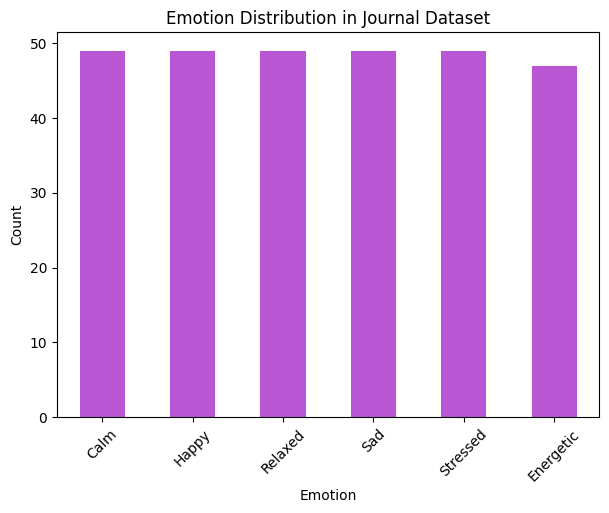

In [29]:
plt.figure(figsize=(7,5))
journal["detected_emotion"].value_counts().plot(kind="bar", color="mediumorchid")
plt.title("Emotion Distribution in Journal Dataset")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


Confusion Matrix (BERT, 6 emotions)

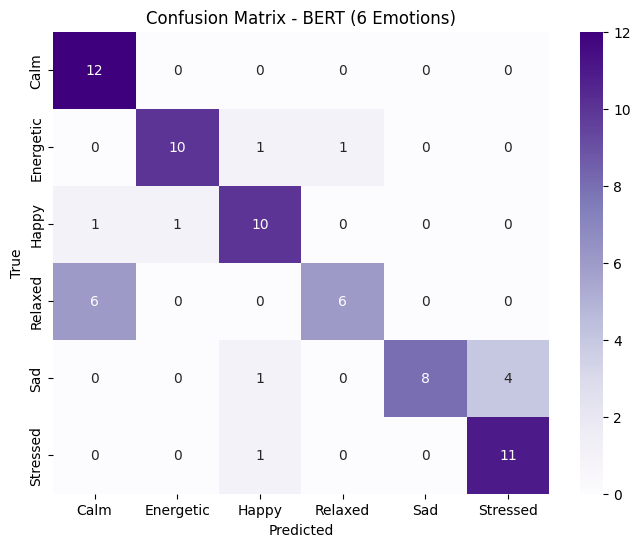

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title("Confusion Matrix - BERT (6 Emotions)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


ROC Curves (One-vs-Rest)

In [31]:
import torch.nn.functional as F

probs = []
true = []   # overwrite to ensure correct shape

model_bert.eval()

with torch.no_grad():
    for batch in test_loader:
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model_bert(**batch)
        logits = outputs.logits
        
        # Softmax to convert logits → probabilities
        prob = F.softmax(logits, dim=1)
        
        probs.extend(prob.cpu().numpy())
        true.extend(batch["labels"].cpu().numpy())

probs = np.array(probs)
true = np.array(true)

print("Shape of probs:", probs.shape)
print("Shape of true:", true.shape)


Shape of probs: (73, 6)
Shape of true: (73,)


In [32]:
from sklearn.preprocessing import label_binarize

true_bin = label_binarize(true, classes=list(range(len(emotion_labels))))
print("true_bin shape:", true_bin.shape)


true_bin shape: (73, 6)


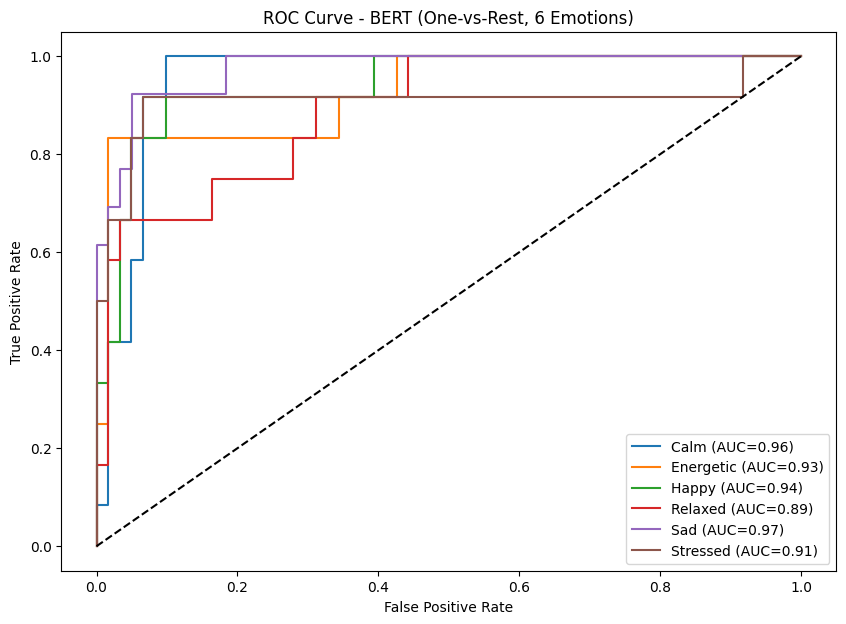

In [33]:
plt.figure(figsize=(10,7))

for i, label in enumerate(emotion_labels):
    fpr, tpr, _ = roc_curve(true_bin[:, i], probs[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.title("ROC Curve - BERT (One-vs-Rest, 6 Emotions)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


Precision–Recall Curves

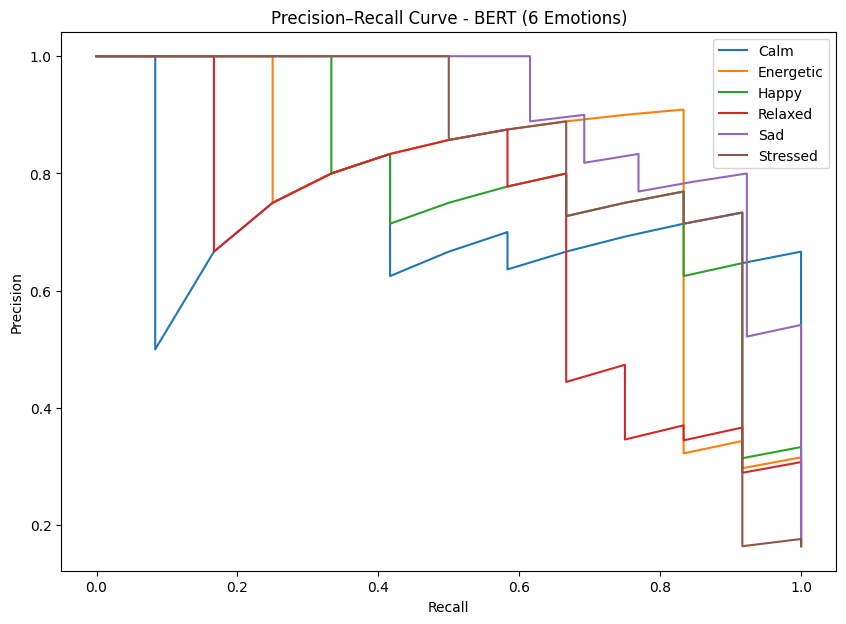

In [34]:
plt.figure(figsize=(10,7))

for i, label in enumerate(emotion_labels):
    precision, recall, _ = precision_recall_curve(true_bin[:, i], probs[:, i])
    plt.plot(recall, precision, label=f"{label}")

plt.title("Precision–Recall Curve - BERT (6 Emotions)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


Training Loss Curve

In [35]:
loss_values = []

epochs = 7
model_bert.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in train_loader:
        optim.zero_grad()
        batch = {k:v.to(device) for k,v in batch.items()}
        outputs = model_bert(**batch)
        loss = outputs.loss
        loss.backward()
        optim.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_values.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")


Epoch 1/7 - Loss: 0.0024
Epoch 2/7 - Loss: 0.0021
Epoch 3/7 - Loss: 0.0021
Epoch 4/7 - Loss: 0.0019
Epoch 5/7 - Loss: 0.0018
Epoch 6/7 - Loss: 0.0017
Epoch 7/7 - Loss: 0.0016


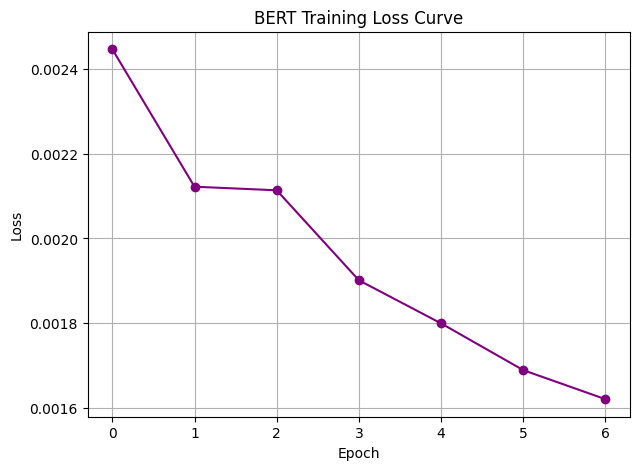

In [36]:
plt.figure(figsize=(7,5))
plt.plot(loss_values, marker='o', color='purple')
plt.title("BERT Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


Misclassification Analysis (Top 10 Errors)

In [37]:
misclassified = []

for i, (t, p) in enumerate(zip(true, preds)):
    if t != p:
        misclassified.append((test_texts[i], emotion_labels[t], emotion_labels[p]))

misclassified[:10]


[('i felt my heart beating fast', 'Stressed', 'Happy'),
 ('i struggled to find motivation', 'Sad', 'Stressed'),
 ('the whole day felt calm and restful', 'Relaxed', 'Calm'),
 ('i missed someone deeply today', 'Sad', 'Happy'),
 ('the slow pace of the day felt perfect', 'Relaxed', 'Calm'),
 ('sunshine boosted my motivation', 'Energetic', 'Happy'),
 ('i felt no fatigue today', 'Energetic', 'Relaxed'),
 ('my body felt loose and peaceful', 'Relaxed', 'Calm'),
 ('i lay back and stared at the ceiling peacefully', 'Relaxed', 'Calm'),
 ('i didn t feel excited about anything', 'Sad', 'Stressed')]

TF-IDF Feature Importance (Baseline Model)

In [38]:
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

topn = 15
feature_names = np.array(tfidf.get_feature_names_out())

for emotion in emotion_labels:
    idx = list(y_train.astype("category").cat.categories).index(emotion)
    top_features = np.argsort(lr.coef_[idx])[-topn:]
    
    print(f"\nTop words for emotion: {emotion}")
    for feat in reversed(feature_names[top_features]):
        print(feat)



Top words for emotion: Calm
peaceful
slowly
calm
quiet
silence
silence felt
felt comforting
comforting
felt peace
peace
gentle
soft music
watching
room
brought

Top words for emotion: Energetic
felt ready
ready
fast
extremely
energy
strong
usual
work
awake
quickly
moved constantly
multitasked ease
multitasked
conversations exciting
exciting

Top words for emotion: Happy
happy
joyful
happiness
smiled
enjoyed
today
good
mood
positive
moment
bright
felt bright
felt joyful
way
joy

Top words for emotion: Relaxed
relaxed
allowed
ease
slow
soft
helped
comfort
evening
gently
helped unwind
mind
tense today
body
embraced doing
moved

Top words for emotion: Sad
sadness
like
emotions
didn
memories
sad
felt like
people
felt
felt emotionally
crying
like crying
emotionally
didn feel
avoided conversations

Top words for emotion: Stressed
felt
couldn
felt overwhelmed
overwhelmed
irritated
mentally
worries
responsibilities
day
urgent
felt urgent
felt mentally
struggled tasks
demanded
demanded energy


Calibration Curve

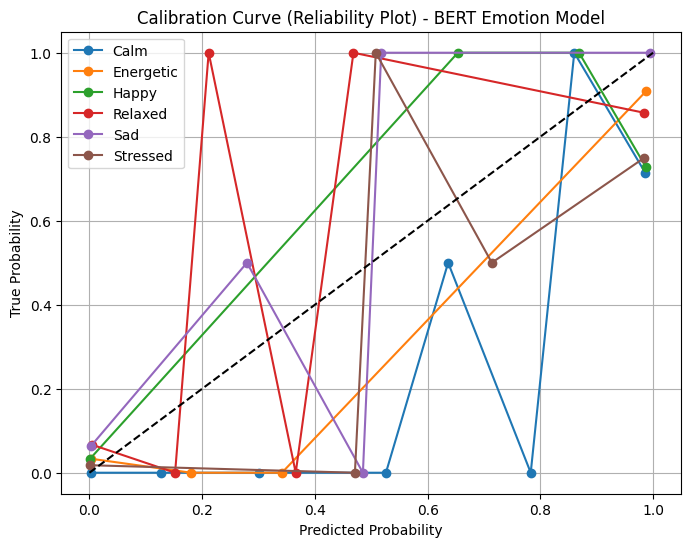

In [39]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8,6))

for i, label in enumerate(emotion_labels):
    fraction_pos, mean_pred = calibration_curve(true_bin[:, i], probs[:, i], n_bins=10)
    plt.plot(mean_pred, fraction_pos, marker='o', label=label)

plt.plot([0, 1], [0, 1], "k--")
plt.title("Calibration Curve (Reliability Plot) - BERT Emotion Model")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.legend()
plt.grid(True)
plt.show()


Misclassification Heatmap

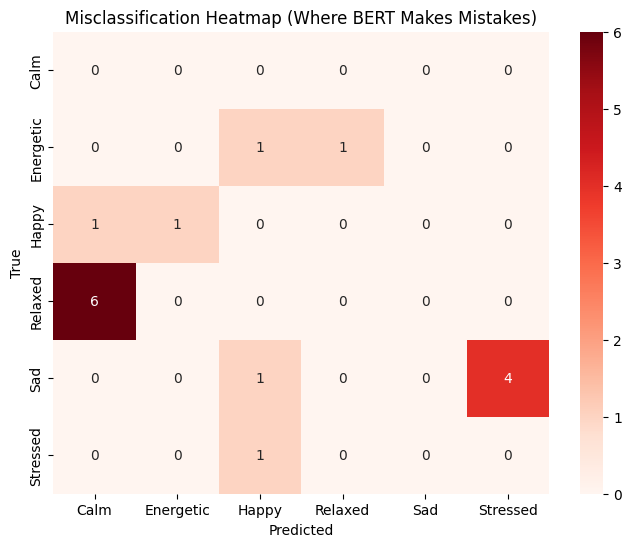

In [40]:
# Build misclassification matrix
import numpy as np

num_classes = len(emotion_labels)
error_matrix = np.zeros((num_classes, num_classes), dtype=int)

for t, p in zip(true, preds):
    if t != p:
        error_matrix[t][p] += 1

plt.figure(figsize=(8,6))
sns.heatmap(error_matrix, annot=True, fmt="d", cmap="Reds",
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title("Misclassification Heatmap (Where BERT Makes Mistakes)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
